<a href="https://colab.research.google.com/github/anyuanay/info212/blob/main/INFO212_Week5_Lecture_Plot_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INFO 212: Data Science Programming 1
___

## Week 5: Lecture: Pandas, Plot, and Visualization
---

**Agenda:**
- Introduction to data visualization
- About Figures, Axes, and Axis
- Univariate plots
- Bivariate Plots
- Colors, markers, and line styles
- Ticks and legends
- Plotting with seaborn
- An application on map

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pandas (continue from last lecture)

In [ ]:
# pd.read_csv("train.csv")


# df.apply(f) - Applying Functions

Apply a function along the axis of the DataFrame (rows or columns). apply() is a powerful way to manipulate pandas data structures, making it a key method in data transformation and preparation tasks.

- When used on a Series, apply() allows you to apply a function to each element in the Series.
- When used on a DataFrame, you can apply a function along each column or row. The axis is specified using axis parameter:
 - axis=0 or axis='index' (default) applies the function to each column.
 - axis=1 or axis='columns' applies the function to each row.
- apply() is commonly used with lambda functions for quick operations without defining a separate function.


```
df = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6]
})

# Function to calculate the sum of each row
def row_sum(row):
    return row.sum()

# Applying the function across rows
df.apply(row_sum, axis=1)
```

```
df.apply(lambda x: x.sum())
```

## Exercise:
Use apply() to create a new column 'AgeCategory' so that the passengers are categoried into 'child' if Age <= 18, 'youth' if 18 < Age < 30, and 'adult' if Age >= 30.

```
def age_category(age):
    if age <= 18:
        return 'Child'
    elif age < 30:
        return 'Youth'
    else:
        return 'Adult'

df['AgeCategory'] = df['Age'].apply(age_category)
```

# df.sort_values(by) - Sorting by Values

Sorts the rows based on the values in a particular column.
```
df.sort_values(by='Age')
```

## Exercise:
Sort the passengers in the DataFrame by their ticket fares in ascending and descending order.

# df.sort_index(axis) - Sorting by Index

Sorts the DataFrame based on its index (row or column names).
```
df.sort_index(axis=1)
```

## Exercise:
Sort the columns by their names by ascending and descending from left to right.

# Introduction to Data Visualization
- Importance of Informative Visualizations:
 * Central task in data analysis
 * Aids in the exploratory process
 * Helps identify outliers & data transformations
 * Generates ideas for models
- End Goal for Some:
 * Building interactive web visualizations
- Python's Capabilities:
 * Numerous add-on libraries
 * Supports both static and dynamic visualizations

 ![](https://i.imgur.com/h2wyqTx.png)

# Why is Data Visualization so Important?

## Exercise 1:
In this exercise you will find the importance of data visualization vs. numerical summary. Anscombe's quartet comprises four data sets that have nearly identical simple descriptive statistics, yet have very different distributions and appear very different when graphed.

Load the file "anscombes.csv" as a Pandas DataFrame.
Compute the mean and variance of each dataset identified by the ids I, II, III, IV.
Plot the dataset identified by the ids I, II, III, IV for comparison.

# About Figures, Axes, and Axis
Matplotlib graphs your data on `Figures` (e.g., windows, Jupyter widgets, etc.), each of which can contain one or more `Axes`, an area where points can be specified in terms of x-y coordinates (or theta-r in a polar plot, x-y-z in a 3D plot, etc.). The simplest way of creating a Figure with an Axes is using pyplot.subplots. We can then use Axes.plot to draw some data on the Axes.
- Figure: The whole figure. Think of it as the 'canvas' for your painting.
- Axes: This is what you think of as 'a plot', it is the region of the image with the data space (bounded by the x-axis and y-axis).
- Axis: These are the number-line-like objects that take care of setting the graph limits and generating the ticks and ticklabels.


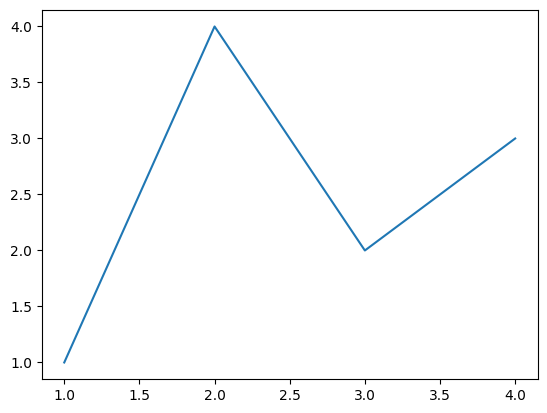

In [ ]:
fig, ax = plt.subplots()  # Create a figure containing a single axes.
ax.plot([1, 2, 3, 4], [1, 4, 2, 3])  # Plot some data on the axes.

## Parts of a Figure
Here are the components of a Matplotlib Figure. Figure, Axes, and Axis refer to different parts of a plot. Understanding these components is crucial for effectively using the library to create and customize visualizations.

![matplotlib figure](https://i.imgur.com/SIHDY22.png)

## Figures
The whole figure. The Figure keeps track of all the child Axes, a group of 'special' Artists (titles, figure legends, colorbars, etc), and even nested subfigures. The easiest way to create a new Figure is with pyplot:

<Figure size 640x480 with 0 Axes>

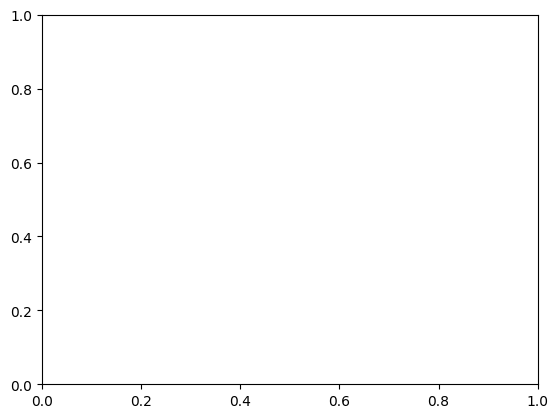

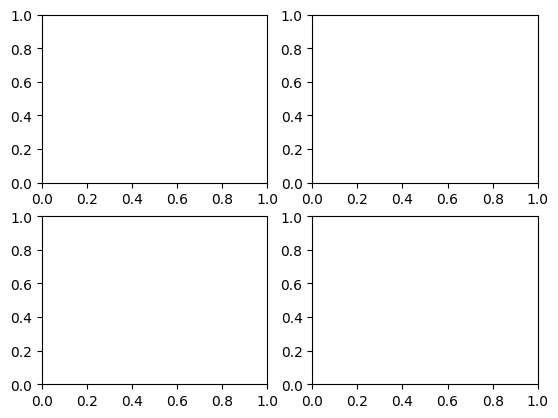

In [ ]:
fig = plt.figure()  # an empty figure with no Axes
fig, ax = plt.subplots()  # a figure with a single Axes
fig, axs = plt.subplots(2, 2)  # a figure with a 2x2 grid of Axes

## Axes
An Axes is an Artist attached to a Figure that contains a region for plotting data, and usually includes two (or three in the case of 3D) Axis objects (be aware of the difference between Axes and Axis) that provide ticks and tick labels to provide scales for the data in the Axes. Each Axes also has a title (set via set_title()), an x-label (set via set_xlabel()), and a y-label set via set_ylabel()).

## Axis
These objects set the scale and limits and generate ticks (the marks on the Axis) and ticklabels (strings labeling the ticks).

# We can plot using Pandas
- Pandas can load and transform data
- Pandas also provides easy-to-use and expressive plotting API.

# We can plot using special library such as seaborn
- seaborn is a statistical graphics library.
- seaborn simplifies creating many common visualization types.
- With data that requires aggregation or summarization before making a plot, using the seaborn package can make things much simpler.

# Load a Dataset

In [ ]:
# Cardiovascular Disease dataset
file = "/content/drive/MyDrive/Colab Notebooks/courses/INFO212/CVD_cleaned.csv"

In [6]:
# Show the shape and head


In [7]:
# show the columns


In [8]:
# show info


In [9]:
# show summary statistics


In [10]:
# show summary statistics of object columns


# Univariate Plot
- Univariate plots visualize data one variable at a time. They help in understanding the distribution, central tendencies, and variability of the data.

- Importance: Before delving deep into complex multivariate visualizations, understanding the basics of each variable is essential. Univariate plots offer insights into the nature of a variable (whether it's normally distributed, skewed, has outliers, etc.).

- Numerical Data: This refers to data that is quantifiable and is typically represented as numbers.
 * Visualization Techniques: Histograms are great for understanding the distribution of the data. Boxplots, on the other hand, provide a summary of the central tendency, variability, and outliers in the dataset.

- Categorical Data: This type of data represents categories or labels. These can't be measured in quantitative terms but can be counted or grouped.
 * Visualization Techniques: Bar charts are suitable for comparing the frequency of different categories. Pie charts provide a proportionate representation of each category in a whole.

## Histogram
- A histogram visualizes the distribution of a continuous numerical dataset by grouping the data into 'bins' or intervals.
- The width of the bins can be consistent or variable. The height of each bar represents the frequency of data points within that bin. For example, a histogram could show how many people fall into specific age groups (0-10, 10-20, etc.).

In [11]:
# plot histogram for BMI


## Bar charts and categorical data
- Bar charts map categories to numbers: for example, the amount of eggs consumed for breakfast (a category) to a number breakfast-eating Americans; or, in our case, wine-producing provinces of the world (category) to the number of labels of wines they produce (number).

In [17]:
# plot bar charts of Age_Category categories sorted by index


## Box plot
- Box plots offer a summarized view of the data distribution, highlighting central tendency, spread, and skewness.
- Components of Box Plot:
 * Median: Central value
 * IQR: Middle 50% of data
 * Whiskers: Data spread outside the IQR
 * Outliers: Unusual data points
- Purpose & Use:
 * Summarizes data distribution
 * Easily compare multiple groups
 * Identifies skewness and potential outliers

In [13]:
# box plot for Fruit_Consumption


In [14]:
# box plot Fruit_Consumption < 60


## Pie plot


In [15]:
# pie plot for General_Health


## Line charts
- For the points values as real number, line charts should be the first choice for visualizing the distribution.

In [16]:
# line plot for Age_Category categories sorted by index


## Area charts
- Area charts are just line charts, but with the bottom shaded in. That's it!

In [18]:
# area plot Diabeties


# Density plots
Kernel density estimate (KDE) plot is type of a smoothed histogram.

To make a KDE plot, we use the sns.kdeplot command. Setting shade=True colors the area below the curve (and data= chooses the column we would like to plot).

In [19]:
# Use seaborn kdeplot for Height_(cm) with shape=True


In [20]:
# kdeplot for BMI


# Bivariate Plot
- Two Variables: Bivariate plots provide insights into the relationship between two different variables.
- Relationships or Disparities: They can highlight whether there's a connection between the variables, whether they move in tandem (positive correlation), move in opposite directions (negative correlation), or if there's no discernible pattern.

- Common Types of Bivariate Plots:

 * Scatter Plots: Points plotted in two dimensions; often used to see if two variables have a linear relationship.
 * Line Graphs: Usually displays a series of data points connected by straight line segments; can be useful in observing trends over continuous data.
 * Hexbin Plots: Used when dealing with a lot of data points; it groups points in hexagonal bins and then color-codes those bins based on the number of points they contain.
 * Contour Plots: Useful to represent three-dimensional data in two dimensions; shows areas where there is a high density of data points.

- Usage of Bivariate Plots:

 * Identifying Trends: Spot patterns between two variables.
Spotting Outliers: Identify data points that don't follow the general trend.
 * Assessing Correlation: Understand if and how strongly two variables are related.

## Scatter plot
- Scatter plots use dots to represent values of two numerical variables. The position of each dot on the horizontal (X) and vertical (Y) axis shows the value for an individual data point.

In [21]:
# scatter plot BMI vs. Weight_(kg)


## Bivariate line plot
- Let us illustrate the relationship between the BMI and FriedPotato_Consumption for a random subset of 1000 people:

 * The x-axis represents the BMI of the people.
 * The y-axis represents the FriedPotato_Consumption of the people.

In [22]:
# randomly sample 1000 people


In [23]:
# line plot BMI vs. FriedPotato_Consumption for the 1000 samples


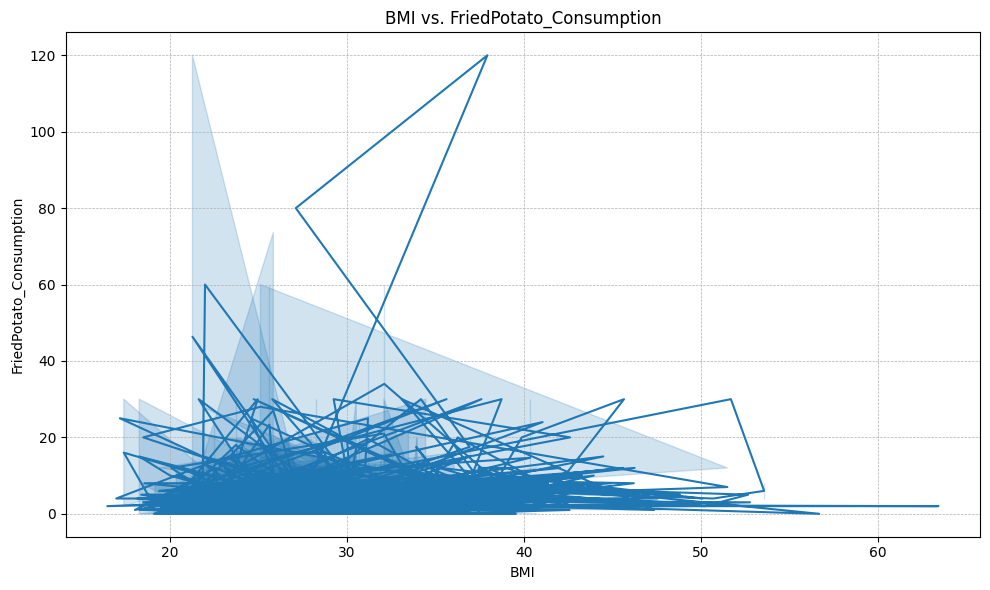

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(x='BMI', y='FriedPotato_Consumption', data=sample_people, sort=False)
plt.title('BMI vs. FriedPotato_Consumption')
plt.xlabel('BMI')
plt.ylabel('FriedPotato_Consumption')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()

## Hexbin plot
- A hexbin plot is a bivariate histogram where the plane is divided into hexagons. Each hexagon represents a 'bin' and the number of data points that fall into each bin is represented by the color of the hexagon. Hexbin plots are useful for visualizing the relationship between two numerical variables, especially when there are many data points, which could lead to overplotting in scatter plots.

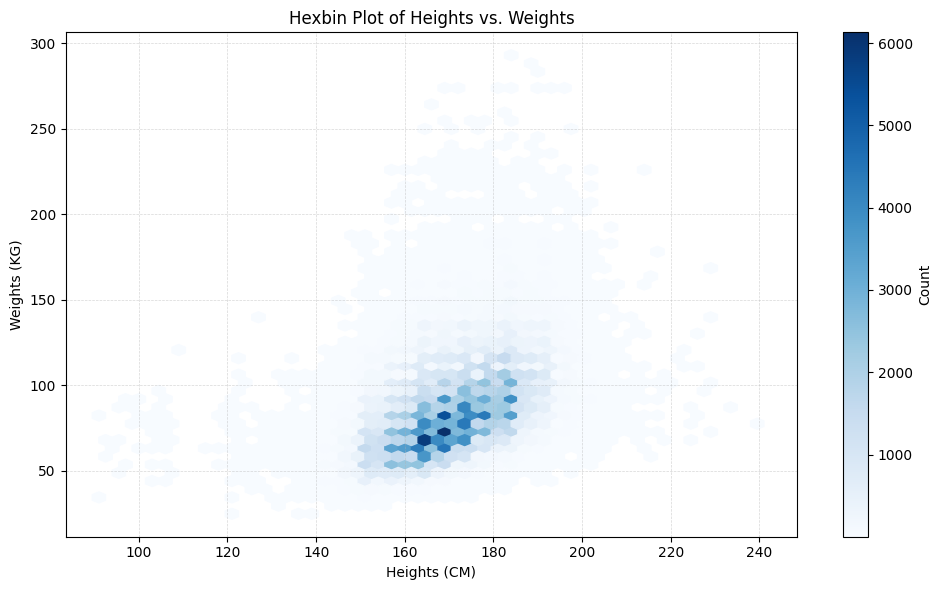

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
plt.hexbin(df['Height_(cm)'], df['Weight_(kg)'], gridsize=50, cmap='Blues', mincnt=1)
plt.colorbar(label='Count')
plt.title('Hexbin Plot of Heights vs. Weights')
plt.xlabel('Heights (CM)')
plt.ylabel('Weights (KG)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()

plt.show()

## Contour Plot
- A contour plot, also known as a contour map or level plot, is a graphical technique used to represent a 3-dimensional surface in two dimensions. It's commonly used to display the patterns of response as two predictor variables change. Essentially, it visualizes regions of constant values (contours) on a 2D plane.

<Figure size 1000x600 with 0 Axes>

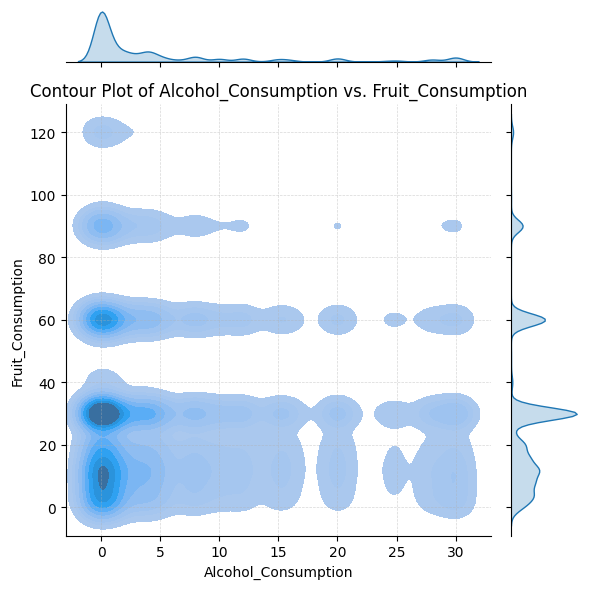

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
sns.jointplot(x=df['Alcohol_Consumption'], y=df['Fruit_Consumption'], kind='kde', fill=True)
plt.title('Contour Plot of Alcohol_Consumption vs. Fruit_Consumption')
plt.xlabel('Alcohol_Consumption')
plt.ylabel('Fruit_Consumption')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()

plt.show()

# Colors, Markers, and Line Styles
- Python visualization libraries provide powerful toosl to change styles of plots

```
ax = df.plot.scatter(x = 'BMI', y = 'Weight_(kg)', \
                                                  figsize = (12, 6), \
                                                  color = 'mediumvioletred', \
                                                  linestyle = '--', \
                                                  fontsize = 16)
ax.set_title('BMI vs. Weights')
```

- We can set markers on plotted lines for data points.

```
from numpy.random import randn
plt.plot(randn(30).cumsum(), color = 'r', linestyle = '--', marker = 'o')
```

# Ticks and Legends
- We can set ticks and legends for plots.

```
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.random.randn(1000).cumsum())
```

```
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.random.randn(1000).cumsum())
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'],
                            rotation=30, fontsize='small')
```

```
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
blue_lines = ax.plot(np.random.randn(1000).cumsum(), label ="Random Numbers")
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'],
                            rotation=30, fontsize='small')
ax.set_title('My first matplotlib plot')
ax.set_ylabel("Random Number")
ax.set_xlabel('Stages')
ax.legend(loc='best')
```

- Add legends to a plot.

```
from numpy.random import randn
fig = plt.figure(); ax = fig.add_subplot(1, 1, 1)
ax.plot(randn(1000).cumsum(), 'k', label='one')
ax.plot(randn(1000).cumsum(), 'k--', label='two')
ax.plot(randn(1000).cumsum(), 'k.', label='three')
ax.legend(loc='best')
```

# How to Save Plots to File?

```
plt.savefig('figpath.svg')
```

```
plt.savefig('figpath.png', dpi=400, bbox_inches='tight')
```

```
plt.plot(randn(30).cumsum(), color = 'r', linestyle = '--', marker = 'o')
plt.savefig('figpath.png', dpi=400, bbox_inches='tight')
```

# Plot the Titanic Data

```
titanic = pd.read_csv("datasets/train.csv")
titanic.head()
```

In [ ]:
df = pd.read_csv("train.csv")

```
import seaborn as sns
```

In [ ]:
import seaborn as sns

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
len(df.columns)

12

```
titanic.Survived.unique()
```

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df['Survived'].value_counts() / len(df)

0    0.616162
1    0.383838
Name: Survived, dtype: float64

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Pclass', ylabel='Age'>

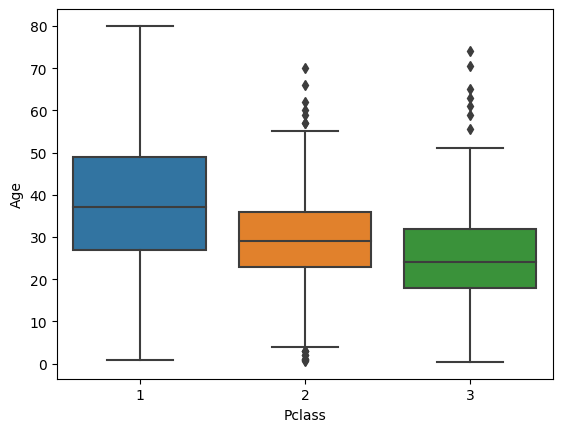

In [ ]:
sns.boxplot(data=df, x='Pclass', y='Age')

- How are the chances of survival related to Age and Pclass?

```
grid = sns.FacetGrid(titanic, col='Survived', row='Pclass', size=3.2, aspect=1.6)
grid.map(plt.hist, 'Age', alpha=.5, bins=20)
grid.add_legend();
```

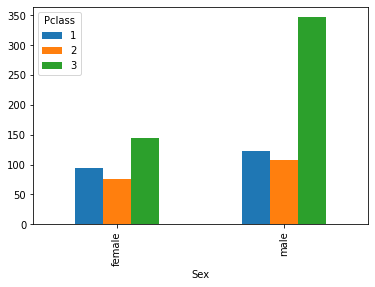

In [ ]:
pd.crosstab(df['Sex'], df['Pclass']).plot.bar()

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

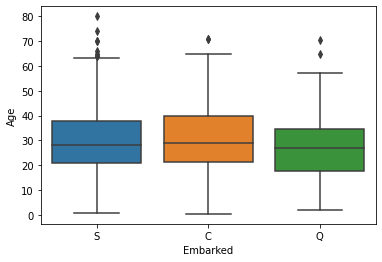

In [ ]:
sns.boxplot(data=df, x='Embarked', y='Age')

In [ ]:
df_nested = df.set_index(['Pclass', 'Sex']).sort_index()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


/usr/local/lib/python3.7/dist-packages/seaborn/axisgrid.py:670: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


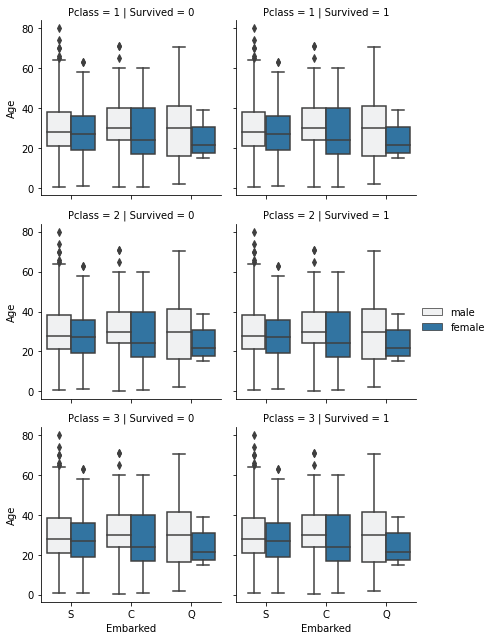

In [ ]:
grid = sns.FacetGrid(df, col = 'Survived', row='Pclass')
grid.map(sns.boxplot, data=df, x='Embarked', y='Age', hue='Sex')
grid.add_legend()

/usr/local/lib/python3.7/dist-packages/seaborn/axisgrid.py:337: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


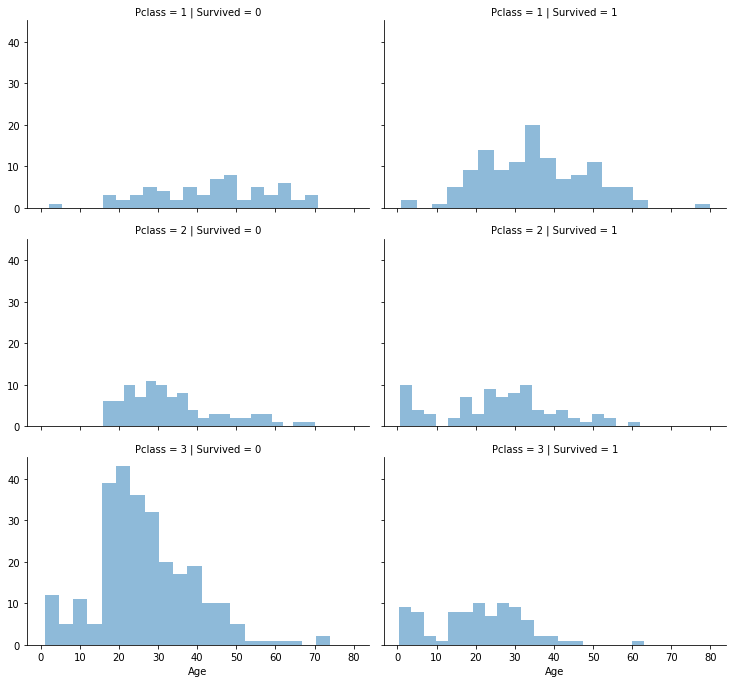

In [ ]:
grid = sns.FacetGrid(df, col='Survived', row='Pclass', size=3.2, aspect=1.6)
grid.map(plt.hist, 'Age', alpha=.5, bins=20)
grid.add_legend();

# Plot the US States

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
files.upload()

Saving US-states.txt to US-states.txt


{'US-states.txt': b'<state name ="Alabama" colour="#ff0000" >\n  <point lat="35.0041" lng="-88.1955"/>\n  <point lat="34.9918" lng="-85.6068"/>\n  <point lat="32.8404" lng="-85.1756"/>\n  <point lat="32.2593" lng="-84.8927"/>\n  <point lat="32.1535" lng="-85.0342"/>\n  <point lat="31.7947" lng="-85.1358"/>\n  <point lat="31.5200" lng="-85.0438"/>\n  <point lat="31.3384" lng="-85.0836"/>\n  <point lat="31.2093" lng="-85.1070"/>\n  <point lat="31.0023" lng="-84.9944"/>\n  <point lat="30.9953" lng="-87.6009"/>\n  <point lat="30.9423" lng="-87.5926"/>\n  <point lat="30.8539" lng="-87.6256"/>\n  <point lat="30.6745" lng="-87.4072"/>\n  <point lat="30.4404" lng="-87.3688"/>\n  <point lat="30.1463" lng="-87.5240"/>\n  <point lat="30.1546" lng="-88.3864"/>\n  <point lat="31.8939" lng="-88.4743"/>\n  <point lat="34.8938" lng="-88.1021"/>\n  <point lat="34.9479" lng="-88.1721"/>\n  <point lat="34.9107" lng="-88.1461"/>\n</state>\n<state name ="Arkansas" colour="#ff0000" >\n  <point lat="33.0225"

```
# Read in the US-states.txt and make a list of longitudinal and latitudinal data
segments = []
points = []

lat_long_regex = r"<point lat=\"(.*)\" lng=\"(.*)\""

with open("US-states.txt", "r") as f:
    lines = [line for line in f]

for line in lines:
    if line.startswith("</state>"):
        for p1, p2 in zip(points, points[1:]):
            segments.append((p1, p2))
        points = []
    s = re.search(lat_long_regex, line)
    if s:
        lat, lon = s.groups()
        points.append((float(lon), float(lat)))
```

In [ ]:
import re

In [ ]:
segments = []
points = []

lat_long_regex = r"<point lat=\"(.*)\" lng=\"(.*)\""

with open("US-states.txt", "r") as f:
    lines = [line for line in f]

for line in lines:
    if line.startswith("</state>"):
        for p1, p2 in zip(points, points[1:]):
            segments.append((p1, p2))
        points = []
    s = re.search(lat_long_regex, line)
    if s:
        lat, lon = s.groups()
        points.append((float(lon), float(lat)))

```
plt.figure(figsize = (12, 8))
for ((lon1, lat1), (lon2, lat2)) in segments:
    plt.plot([lon1, lon2], [lat1, lat2], color = '0.8')
plt.plot(-75.165222, 39.952583, 'bo', label = 'Philadelphia')
plt.legend(loc = 'best')
```

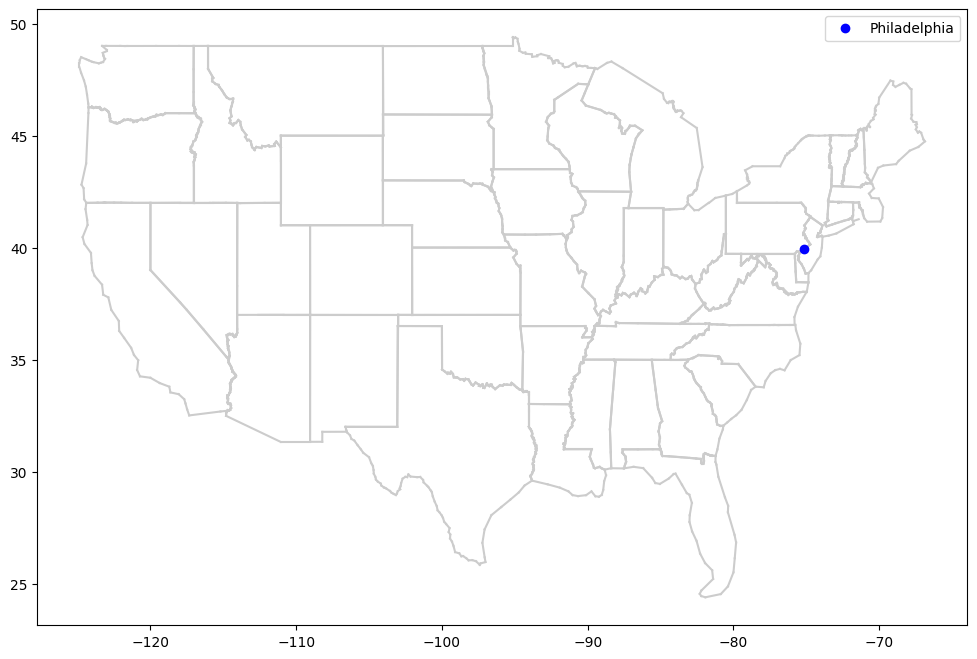

In [ ]:
plt.figure(figsize = (12, 8))
for ((lon1, lat1), (lon2, lat2)) in segments:
    plt.plot([lon1, lon2], [lat1, lat2], color = '0.8')
plt.plot(-75.165222, 39.952583, 'bo', label = 'Philadelphia')
plt.legend(loc = 'best')

**Summary:**
- df.plot.bar()
- df.plot.hist()
- df.plot.box()
- df.plot.pie()
- df.plot.line()
- df.plot.area()
- df.plot.scatter()
- fig = plt.figure()
- ax = fig.add_subplot(1, 1, 1)
- ax.plot(np.random.randn(1000).cumsum(), label ="Random Numbers")
- ax.set_xticks([0, 250, 500, 750, 1000])
- ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'], rotation=30, fontsize='small')
- ax.set_title('My first matplotlib plot')
- ax.set_ylabel("Random Number")
- ax.set_xlabel('Stages')
- ax.legend(loc='best')
- sns.boxplot()
- grid = sns.FacetGrid(df, col = 'Survived', row='Pclass')
- grid.map(sns.boxplot, data=df, x='Embarked', y='Age', hue='Sex')
- grid.add_legend()
- sns.kdeplot(data=df['Age'], shade=True)
- sns.jointplot(x=df['Age'], y=df['Fare'], kind="kde", shade=True)